# UK Financial Services Consumer Complaints Intelligence
## Exploratory Data Analysis - FCA Published Data 2022–2024

**Author:** Prajwal Lawankar  
**Data Source:** FCA Published Firm-Level Complaints Data (firm-level, H1 2022 - H1 2024)  
**Regulatory Context:** Consumer Duty came into force 31 July 2023. This analysis examines whether complaint patterns changed before and after that date.  

---

---
## Cell 1 - Setup & Data Load

In [14]:
# ── IMPORTS ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CHART STYLE ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0F1E2E',
    'axes.facecolor':    '#0F1E2E',
    'axes.edgecolor':    '#1E3A52',
    'axes.labelcolor':   '#94A3B8',
    'axes.titlecolor':   '#E2E8F0',
    'xtick.color':       '#64748B',
    'ytick.color':       '#64748B',
    'text.color':        '#E2E8F0',
    'grid.color':        '#1E3A52',
    'grid.linewidth':    0.6,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     16,
    'figure.dpi':        120,
})

# Colour palette - consistent across all charts
BLUE      = '#3B82F6'
GREEN     = '#10B981'
RED       = '#EF4444'
AMBER     = '#F59E0B'
SLATE     = '#64748B'
PRE_COL   = '#3B82F6'   # Pre-Duty colour
POST_COL  = '#F59E0B'   # Post-Duty colour

# ── LOAD DATA ─────────────────────────────────────────────────────
df = pd.read_csv('./processed/fca_complaints_master.csv')

# ── QUICK DATA QUALITY FIXES ──────────────────────────────────────
# Standardise Scottish Widows capitalisation issue
# (appears as both 'SCOTTISH WIDOWS LIMITED' and 'Scottish Widows Limited')
df['firm_name'] = df['firm_name'].replace(
    'SCOTTISH WIDOWS LIMITED', 'Scottish Widows Limited'
)

# Confirm periods loaded
print('Dataset loaded successfully')
print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(f'Firms: {df.firm_name.nunique():,}  |  Periods: {sorted(df.period_label.unique())}')
print(f'\nPre/Post Duty split:')
print(df.groupby('pre_post_duty')['complaints_opened'].agg(
    records='count', total_complaints='sum'
))

Dataset loaded successfully
Rows: 2,089  |  Columns: 21
Firms: 291  |  Periods: ['H1 2022', 'H1 2023', 'H1 2024', 'H2 2022', 'H2 2023']

Pre/Post Duty split:
               records  total_complaints
pre_post_duty                           
Post-Duty          881           3546835
Pre-Duty          1208           5230929


---
## Chart 1 - Industry Complaint Volume Trend (2022–2024)

**Question this chart answers:**  
Did total complaint volumes across the UK financial services industry rise or fall after Consumer Duty came into force in July 2023?

The vertical dashed line marks July 2023 - the Consumer Duty implementation date.

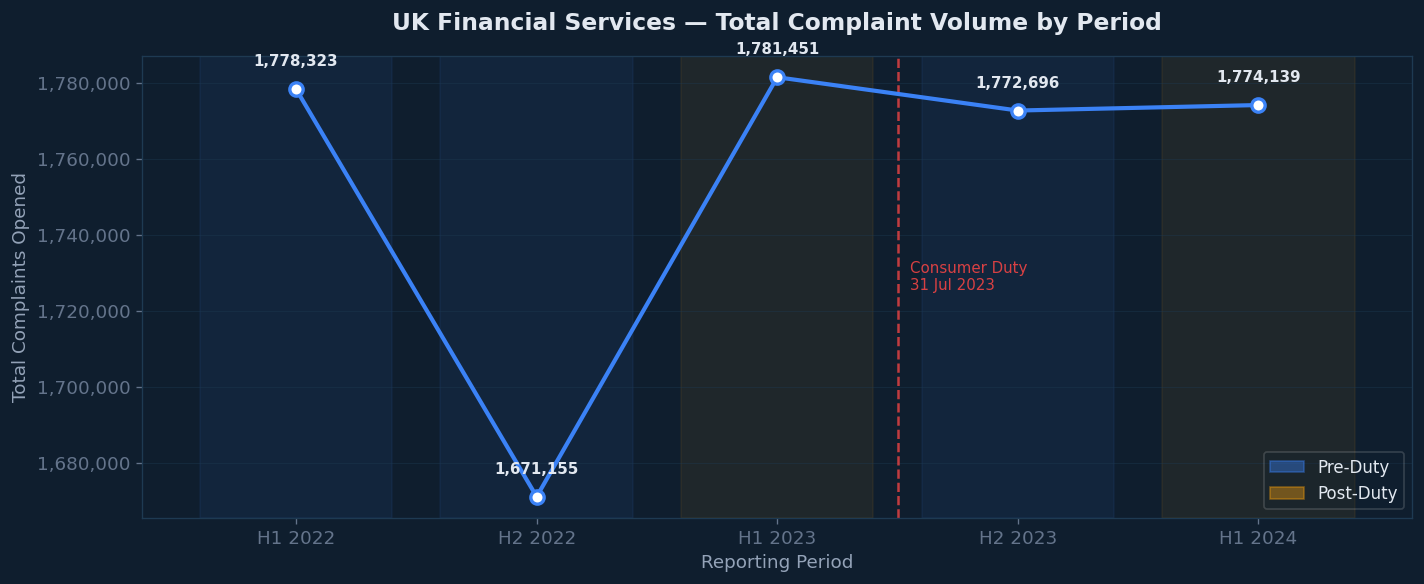

Chart saved.


In [15]:
# Aggregate total complaints per period
period_totals = (
    df.groupby(['period_label', 'period_order', 'pre_post_duty'])
    ['complaints_opened']
    .sum()
    .reset_index()
    .sort_values('period_order')
)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot line
ax.plot(
    period_totals['period_label'],
    period_totals['complaints_opened'],
    color=BLUE, linewidth=2.5, marker='o',
    markersize=8, markerfacecolor='white',
    markeredgecolor=BLUE, markeredgewidth=2,
    zorder=3
)

# Shade pre vs post duty
pre_periods  = period_totals[period_totals['pre_post_duty']=='Pre-Duty']['period_label'].tolist()
post_periods = period_totals[period_totals['pre_post_duty']=='Post-Duty']['period_label'].tolist()

for i, row in period_totals.iterrows():
    col = PRE_COL if row['pre_post_duty']=='Pre-Duty' else POST_COL
    ax.axvspan(i-0.4, i+0.4, alpha=0.07, color=col)

# Consumer Duty line — between H1 2023 and H2 2023
period_labels = period_totals['period_label'].tolist()
if 'H1 2023' in period_labels and 'H2 2023' in period_labels:
    duty_x = period_labels.index('H1 2023') + 0.5
    ax.axvline(x=duty_x, color=RED, linewidth=1.5,
               linestyle='--', alpha=0.8, zorder=2)
    ax.text(duty_x + 0.05, ax.get_ylim()[1] * 0.97,
            'Consumer Duty\n31 Jul 2023',
            color=RED, fontsize=9, va='top', alpha=0.9)

# Value labels on each point
for _, row in period_totals.iterrows():
    ax.annotate(
        f"{row['complaints_opened']:,.0f}",
        xy=(row['period_label'], row['complaints_opened']),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=9, color='#E2E8F0', fontweight='bold'
    )

# Legend
pre_patch  = mpatches.Patch(color=PRE_COL,  alpha=0.4, label='Pre-Duty')
post_patch = mpatches.Patch(color=POST_COL, alpha=0.4, label='Post-Duty')
ax.legend(handles=[pre_patch, post_patch],
          loc='lower right', framealpha=0.2, fontsize=10)

ax.set_title('UK Financial Services — Total Complaint Volume by Period')
ax.set_xlabel('Reporting Period')
ax.set_ylabel('Total Complaints Opened')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'
))
ax.grid(axis='y', alpha=0.4)
ax.set_xticks(range(len(period_labels)))
ax.set_xticklabels(period_labels)

plt.tight_layout()
plt.savefig('./processed/chart_01_industry_volume_trend.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 2 - Top 15 Firms by Total Complaint Volume

**Question this chart answers:**  
Which firms generated the most complaints across the full dataset? Are the highest-volume firms also the ones with the highest uphold rates - or are they simply large firms with proportionately normal complaint rates?

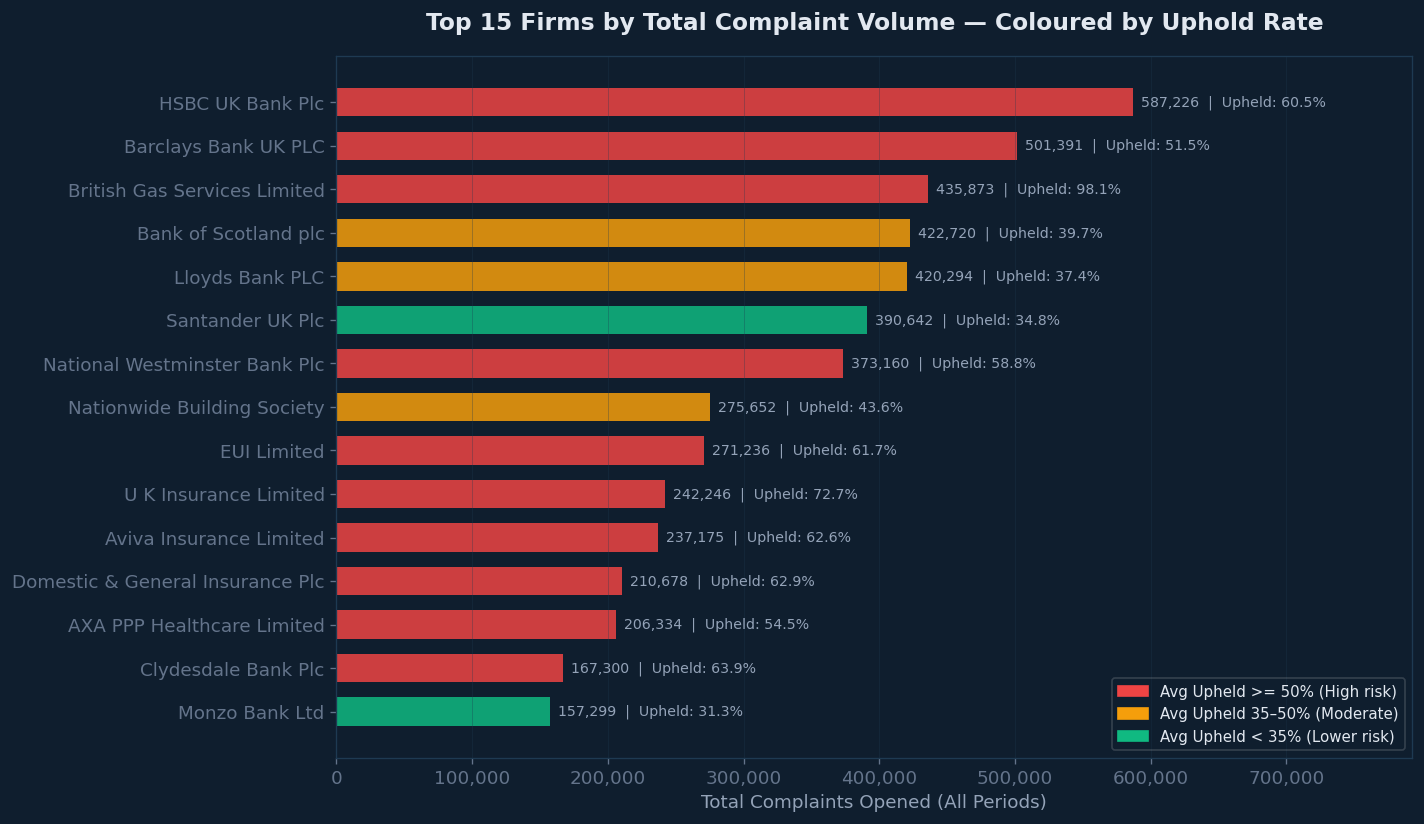

Chart saved.


In [16]:
firm_totals = (
    df.groupby(['firm_name', 'firm_type'])
    .agg(
        total_opened=('complaints_opened', 'sum'),
        avg_upheld=('upheld_pct', 'mean')
    )
    .reset_index()
    .sort_values('total_opened', ascending=False)
    .head(15)
    .sort_values('total_opened', ascending=True)  # flip for horizontal bar
)

# Colour bars by upheld rate
def bar_colour(upheld):
    if upheld >= 50:  return RED
    if upheld >= 35:  return AMBER
    return GREEN

colours = [bar_colour(u) for u in firm_totals['avg_upheld']]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    firm_totals['firm_name'],
    firm_totals['total_opened'],
    color=colours, height=0.65, alpha=0.85
)

# Add value + uphold label at end of each bar
for bar, (_, row) in zip(bars, firm_totals.iterrows()):
    ax.text(
        bar.get_width() + firm_totals['total_opened'].max() * 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{row['total_opened']:,.0f}  |  Upheld: {row['avg_upheld']:.1f}%",
        va='center', fontsize=8.5, color='#94A3B8'
    )

# Legend
red_p   = mpatches.Patch(color=RED,   label='Avg Upheld >= 50% (High risk)')
amber_p = mpatches.Patch(color=AMBER, label='Avg Upheld 35–50% (Moderate)')
green_p = mpatches.Patch(color=GREEN, label='Avg Upheld < 35% (Lower risk)')
ax.legend(handles=[red_p, amber_p, green_p],
          loc='lower right', framealpha=0.2, fontsize=9)

ax.set_title('Top 15 Firms by Total Complaint Volume — Coloured by Uphold Rate')
ax.set_xlabel('Total Complaints Opened (All Periods)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'
))
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, firm_totals['total_opened'].max() * 1.35)

plt.tight_layout()
plt.savefig('./processed/chart_02_top15_firms_volume.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 3 - Uphold Rate Distribution by Firm Type

**Question this chart answers:**  
Which type of firm - retail bank, insurer, investment platform, life and pensions provider - has the worst uphold rate problem? Is it concentrated in one sector or spread across all of them?

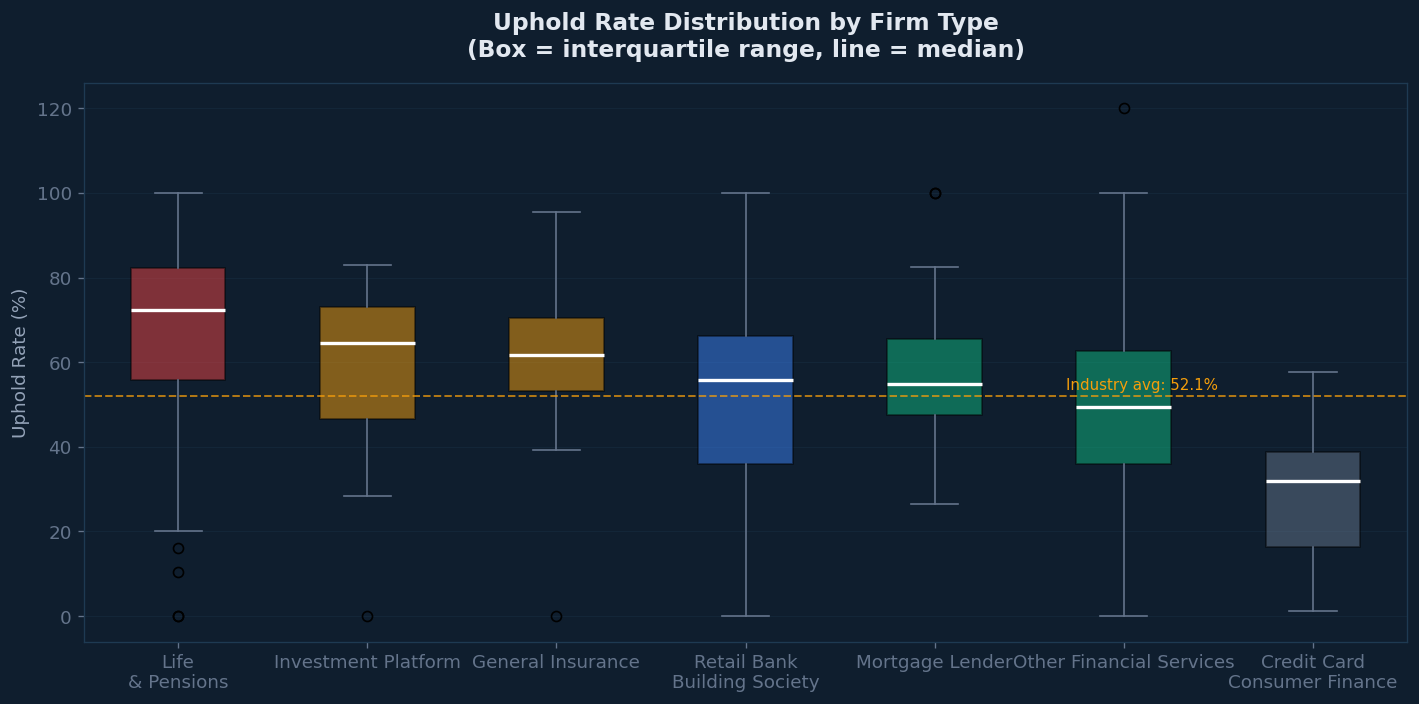

Chart saved.


In [17]:
# Filter to firms with meaningful data
upheld_data = df[df['upheld_pct'].notna()].copy()

# Order firm types by median uphold rate
order = (
    upheld_data.groupby('firm_type')['upheld_pct']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))

# Box plot
box_data = [upheld_data[upheld_data['firm_type']==ft]['upheld_pct'].dropna() for ft in order]

bp = ax.boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    notch=False,
    labels=[ft.replace(' / ', '\n').replace(' & ', '\n& ') for ft in order]
)

box_colours = [RED, AMBER, AMBER, BLUE, GREEN, GREEN, SLATE]
for patch, colour in zip(bp['boxes'], box_colours[:len(bp['boxes'])]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.5)
for whisker in bp['whiskers']:
    whisker.set_color('#64748B')
for cap in bp['caps']:
    cap.set_color('#64748B')
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)

# Reference line - industry average
industry_avg = upheld_data['upheld_pct'].mean()
ax.axhline(y=industry_avg, color=AMBER, linewidth=1.2,
           linestyle='--', alpha=0.7)
ax.text(len(order) - 0.5, industry_avg + 1.5,
        f'Industry avg: {industry_avg:.1f}%',
        color=AMBER, fontsize=9, ha='right')

ax.set_title('Uphold Rate Distribution by Firm Type\n(Box = interquartile range, line = median)')
ax.set_ylabel('Uphold Rate (%)')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./processed/chart_03_uphold_by_firmtype.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 4 - Product Category: Pre vs Post Consumer Duty

**Question this chart answers:**  
Which product categories got worse after Consumer Duty came in, and which improved? The regulation was supposed to improve outcomes for retail customers - did it?

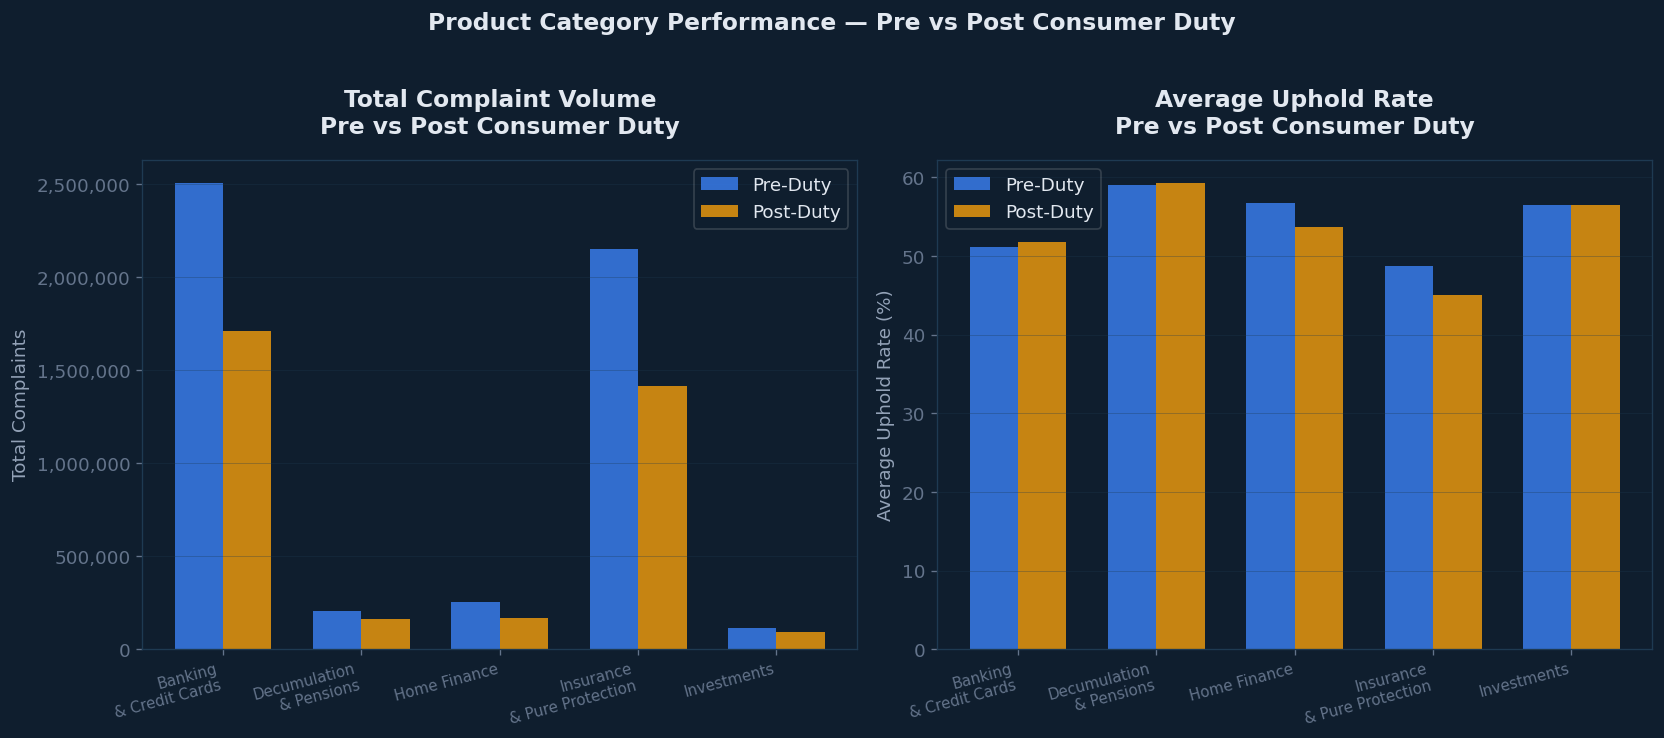

Chart saved.


In [18]:
cat_duty = (
    df.groupby(['product_category', 'pre_post_duty'])
    .agg(
        total_opened=('complaints_opened', 'sum'),
        avg_upheld=('upheld_pct', 'mean')
    )
    .reset_index()
)

# Pivot for grouped bar
pivot = cat_duty.pivot(
    index='product_category',
    columns='pre_post_duty',
    values='total_opened'
).fillna(0)

pivot_upheld = cat_duty.pivot(
    index='product_category',
    columns='pre_post_duty',
    values='avg_upheld'
).fillna(0)

categories = pivot.index.tolist()
x = np.arange(len(categories))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0F1E2E')

# Left — complaint volume
pre_vals  = [pivot.get('Pre-Duty',  pd.Series()).get(c, 0) for c in categories]
post_vals = [pivot.get('Post-Duty', pd.Series()).get(c, 0) for c in categories]

ax1.bar(x - width/2, pre_vals,  width, label='Pre-Duty',  color=PRE_COL,  alpha=0.8)
ax1.bar(x + width/2, post_vals, width, label='Post-Duty', color=POST_COL, alpha=0.8)
ax1.set_title('Total Complaint Volume\nPre vs Post Consumer Duty')
ax1.set_ylabel('Total Complaints')
ax1.set_xticks(x)
ax1.set_xticklabels(
    [c.replace(' & ', '\n& ').replace(' — ', '\n') for c in categories],
    rotation=15, ha='right', fontsize=9
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax1.legend(framealpha=0.2)
ax1.grid(axis='y', alpha=0.3)

# Right - uphold rate
pre_up  = [pivot_upheld.get('Pre-Duty',  pd.Series()).get(c, 0) for c in categories]
post_up = [pivot_upheld.get('Post-Duty', pd.Series()).get(c, 0) for c in categories]

ax2.bar(x - width/2, pre_up,  width, label='Pre-Duty',  color=PRE_COL,  alpha=0.8)
ax2.bar(x + width/2, post_up, width, label='Post-Duty', color=POST_COL, alpha=0.8)
ax2.set_title('Average Uphold Rate\nPre vs Post Consumer Duty')
ax2.set_ylabel('Average Uphold Rate (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(
    [c.replace(' & ', '\n& ').replace(' — ', '\n') for c in categories],
    rotation=15, ha='right', fontsize=9
)
ax2.legend(framealpha=0.2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Product Category Performance — Pre vs Post Consumer Duty',
             fontsize=14, fontweight='bold', y=1.02, color='#E2E8F0')
plt.tight_layout()
plt.savefig('./processed/chart_04_category_pre_post_duty.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 5 - Uphold Rate Heatmap: Firms × Periods

**Question this chart answers:**  
For the top 20 firms by total complaint volume, how did their uphold rate change period by period? A heatmap shows trajectory at a glance - dark red cells indicate sustained high uphold rates.

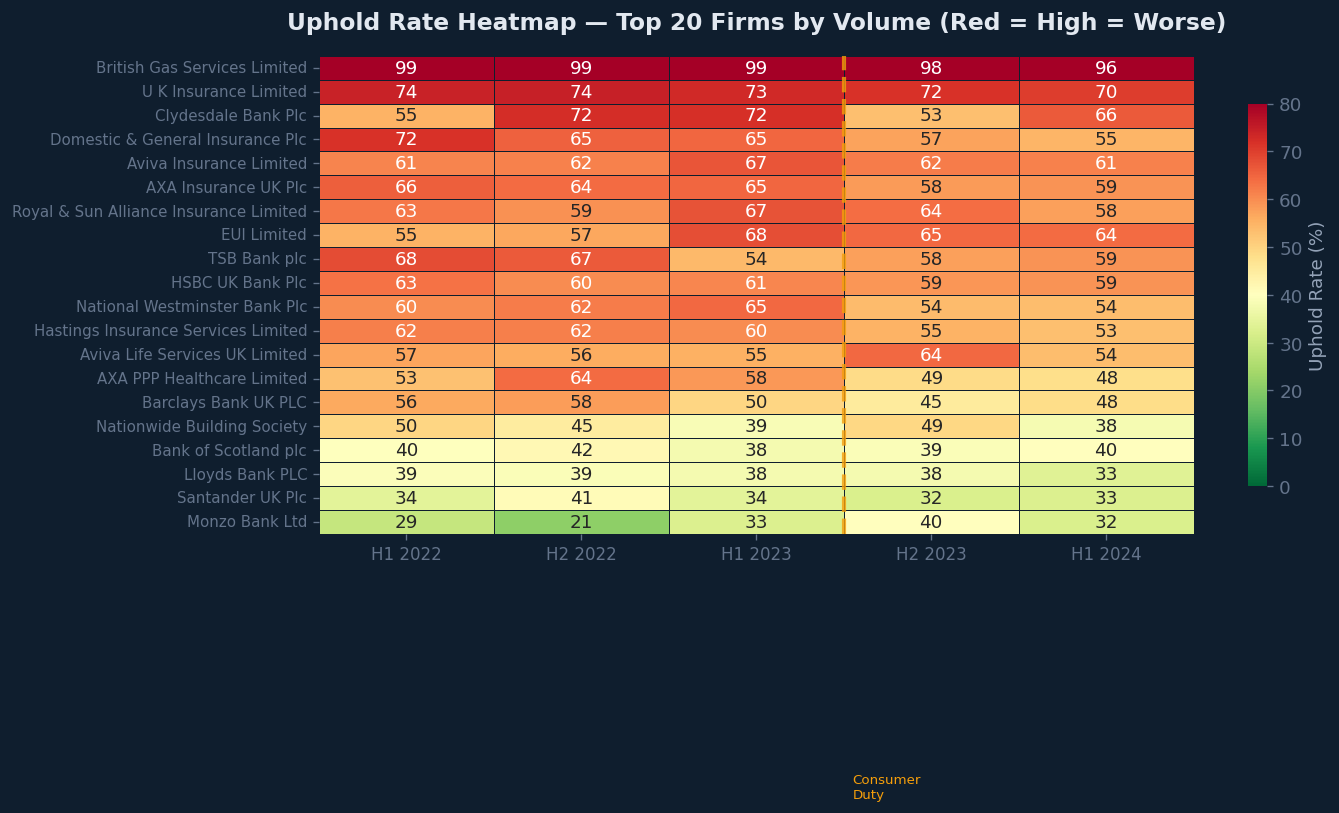

Chart saved.


In [19]:
# Top 20 firms by total complaint volume
top20 = (
    df.groupby('firm_name')['complaints_opened']
    .sum()
    .nlargest(20)
    .index.tolist()
)

heat_data = (
    df[df['firm_name'].isin(top20)]
    .groupby(['firm_name', 'period_label'])['upheld_pct']
    .mean()
    .reset_index()
)

# Period order
period_order = df[['period_label','period_order']].drop_duplicates()
ordered_periods = (
    period_order.sort_values('period_order')['period_label'].tolist()
)

heatmap_pivot = heat_data.pivot(
    index='firm_name', columns='period_label', values='upheld_pct'
)
# Reorder columns chronologically
heatmap_pivot = heatmap_pivot[[c for c in ordered_periods if c in heatmap_pivot.columns]]
# Sort rows by average uphold rate descending
heatmap_pivot = heatmap_pivot.loc[
    heatmap_pivot.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap='RdYlGn_r',   # Red = high uphold (bad), Green = low uphold (good)
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='#0F1E2E',
    vmin=0, vmax=80,
    cbar_kws={'label': 'Uphold Rate (%)', 'shrink': 0.8}
)

ax.set_title('Uphold Rate Heatmap — Top 20 Firms by Volume (Red = High = Worse)')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)

# Mark Consumer Duty boundary between H1 2023 and H2 2023
cols = heatmap_pivot.columns.tolist()
if 'H1 2023' in cols and 'H2 2023' in cols:
    duty_col = cols.index('H2 2023')
    ax.axvline(x=duty_col, color=AMBER, linewidth=2.5, linestyle='--', alpha=0.8)
    ax.text(duty_col + 0.05, -0.5, 'Consumer\nDuty',
            color=AMBER, fontsize=8, va='top', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig('./processed/chart_05_uphold_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 6 - The Danger Quadrant

**Question this chart answers:**  
Which firms sit in the most dangerous position - both high complaint volume AND high uphold rate? These are the firms a regulator would prioritise for supervisory attention under Consumer Duty.

**How to read this chart:**  
- X-axis = total complaint volume (higher = further right)
- Y-axis = average uphold rate (higher = further up)
- Top-right quadrant = Danger Zone
- Bubble size = number of periods the firm appeared in the data

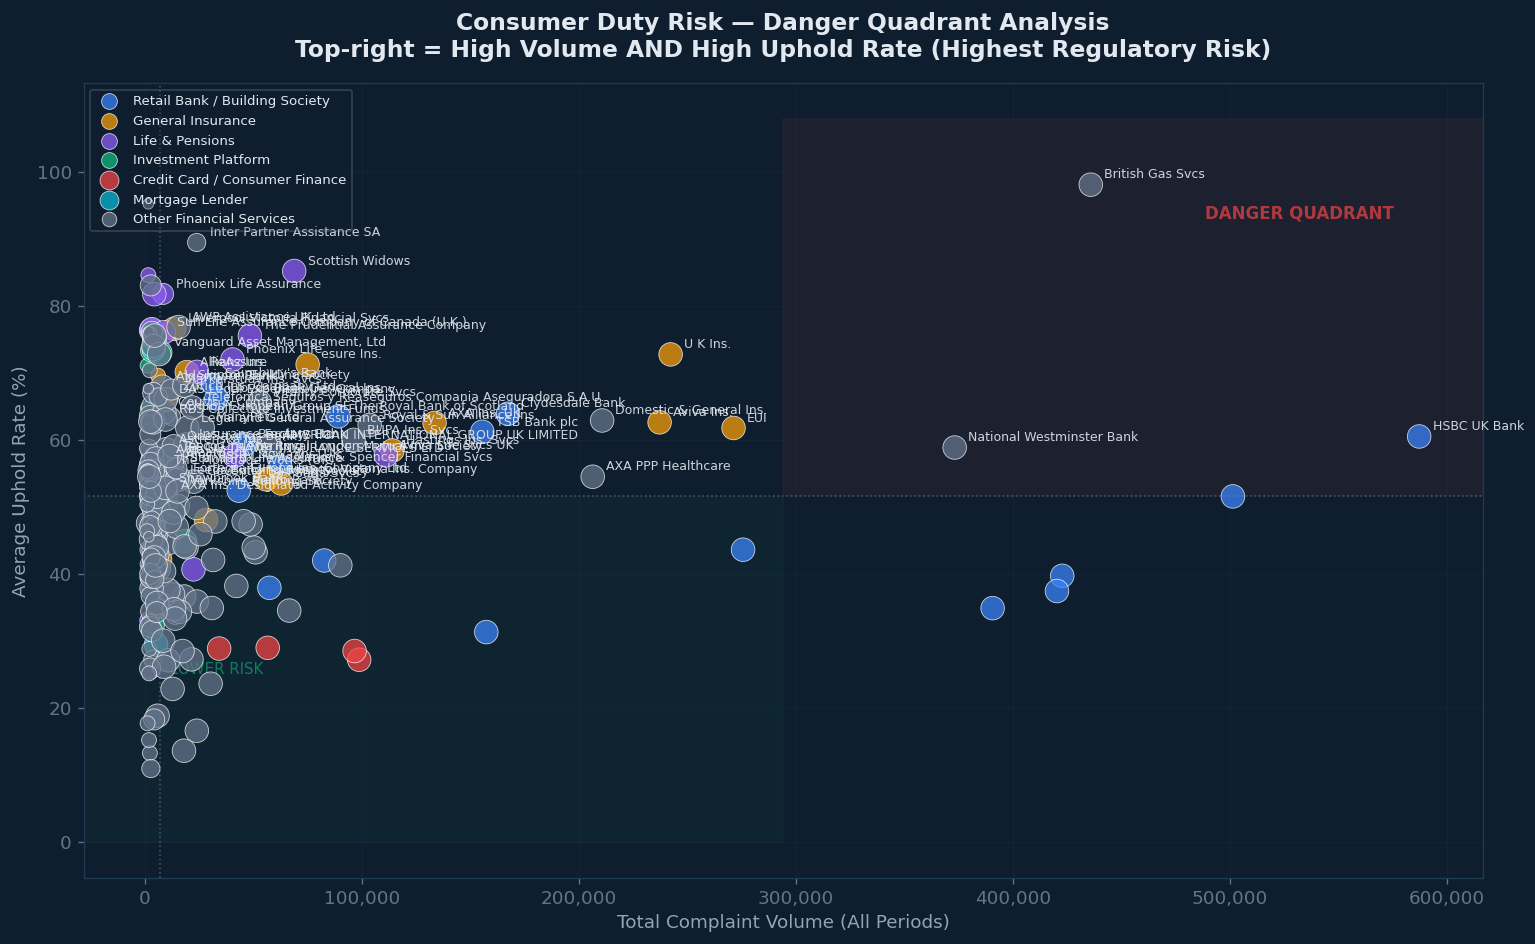

Danger quadrant firms: 65
                                                  firm_name                      firm_type  total_opened  avg_upheld
                    AMERICAN INTERNATIONAL GROUP UK LIMITED       Other Financial Services         57424   59.120000
                                      AWP Assistance UK Ltd       Other Financial Services         15484   76.800000
                  AXA Insurance Designated Activity Company              General Insurance         10294   51.650000
                                       AXA Insurance UK Plc              General Insurance        133465   62.500000
                                 AXA PPP Healthcare Limited       Other Financial Services        206334   54.460000
                                            Acm Ulr Limited       Other Financial Services          8326   57.020000
                      Aioi Nissay Dowa Insurance UK Limited       Other Financial Services         12571   56.340000
                                      

In [20]:
scatter_data = (
    df[df['upheld_pct'].notna()]
    .groupby(['firm_name', 'firm_type'])
    .agg(
        total_opened=('complaints_opened', 'sum'),
        avg_upheld=('upheld_pct', 'mean'),
        periods=('period_label', 'nunique')
    )
    .reset_index()
)
scatter_data = scatter_data[scatter_data['total_opened'] > 1000]

# Thresholds - median of each axis
vol_threshold    = scatter_data['total_opened'].median()
upheld_threshold = scatter_data['avg_upheld'].median()

# Colour by firm type
type_colours = {
    'Retail Bank / Building Society': BLUE,
    'General Insurance':              AMBER,
    'Life & Pensions':                '#8B5CF6',
    'Investment Platform':            GREEN,
    'Credit Card / Consumer Finance': RED,
    'Mortgage Lender':                '#06B6D4',
    'Other Financial Services':       SLATE,
}

fig, ax = plt.subplots(figsize=(13, 8))

# Quadrant shading
ax.axhspan(upheld_threshold, scatter_data['avg_upheld'].max()*1.1,
           xmin=0.5, alpha=0.06, color=RED)   # danger quadrant
ax.axhspan(0, upheld_threshold,
           xmin=0, xmax=0.5, alpha=0.04, color=GREEN)  # safe quadrant

# Threshold lines
ax.axvline(x=vol_threshold, color=SLATE, linewidth=1, linestyle=':', alpha=0.6)
ax.axhline(y=upheld_threshold, color=SLATE, linewidth=1, linestyle=':', alpha=0.6)

# Quadrant labels
ymax = scatter_data['avg_upheld'].max()
xmax = scatter_data['total_opened'].max()
ax.text(xmax * 0.98, ymax * 0.97, 'DANGER QUADRANT',
        ha='right', va='top', color=RED, fontsize=10,
        fontweight='bold', alpha=0.7)
ax.text(xmax * 0.02, upheld_threshold * 0.5, 'LOWER RISK',
        ha='left', va='center', color=GREEN, fontsize=9, alpha=0.6)

# Plot each firm type
for firm_type, colour in type_colours.items():
    subset = scatter_data[scatter_data['firm_type'] == firm_type]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['total_opened'],
        subset['avg_upheld'],
        s=subset['periods'] * 40,
        color=colour,
        alpha=0.75,
        edgecolors='white',
        linewidth=0.5,
        label=firm_type,
        zorder=3
    )

# Label danger quadrant firms only
danger = scatter_data[
    (scatter_data['total_opened'] > vol_threshold) &
    (scatter_data['avg_upheld'] > upheld_threshold)
]
for _, row in danger.iterrows():
    # Shorten long firm names for readability
    name = row['firm_name']
    short = (
        name.replace(' Limited', '').replace(' Plc', '')
            .replace(' PLC', '').replace(' Insurance', ' Ins.')
            .replace(' Services', ' Svcs')
    )
    ax.annotate(
        short,
        xy=(row['total_opened'], row['avg_upheld']),
        xytext=(8, 4), textcoords='offset points',
        fontsize=7.5, color='#E2E8F0', alpha=0.9
    )

ax.set_title('Consumer Duty Risk — Danger Quadrant Analysis\n'
             'Top-right = High Volume AND High Uphold Rate (Highest Regulatory Risk)')
ax.set_xlabel('Total Complaint Volume (All Periods)')
ax.set_ylabel('Average Uphold Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(loc='upper left', framealpha=0.2, fontsize=8, markerscale=0.8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('./processed/chart_06_danger_quadrant.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print(f'Danger quadrant firms: {len(danger)}')
print(danger[['firm_name','firm_type','total_opened','avg_upheld']].to_string(index=False))

## Chart 7 - NatWest Group: Subsidiary Risk Profile

**Question this chart answers:**  
NatWest Group has two subsidiaries in the danger quadrant (National Westminster Bank Plc and The Royal Bank of Scotland Plc). How do their complaint trajectories compare period by period - and did Consumer Duty change anything at group level?

*This is the group-level governance finding that makes this analysis interesting to a Big 4 or bank risk team.*

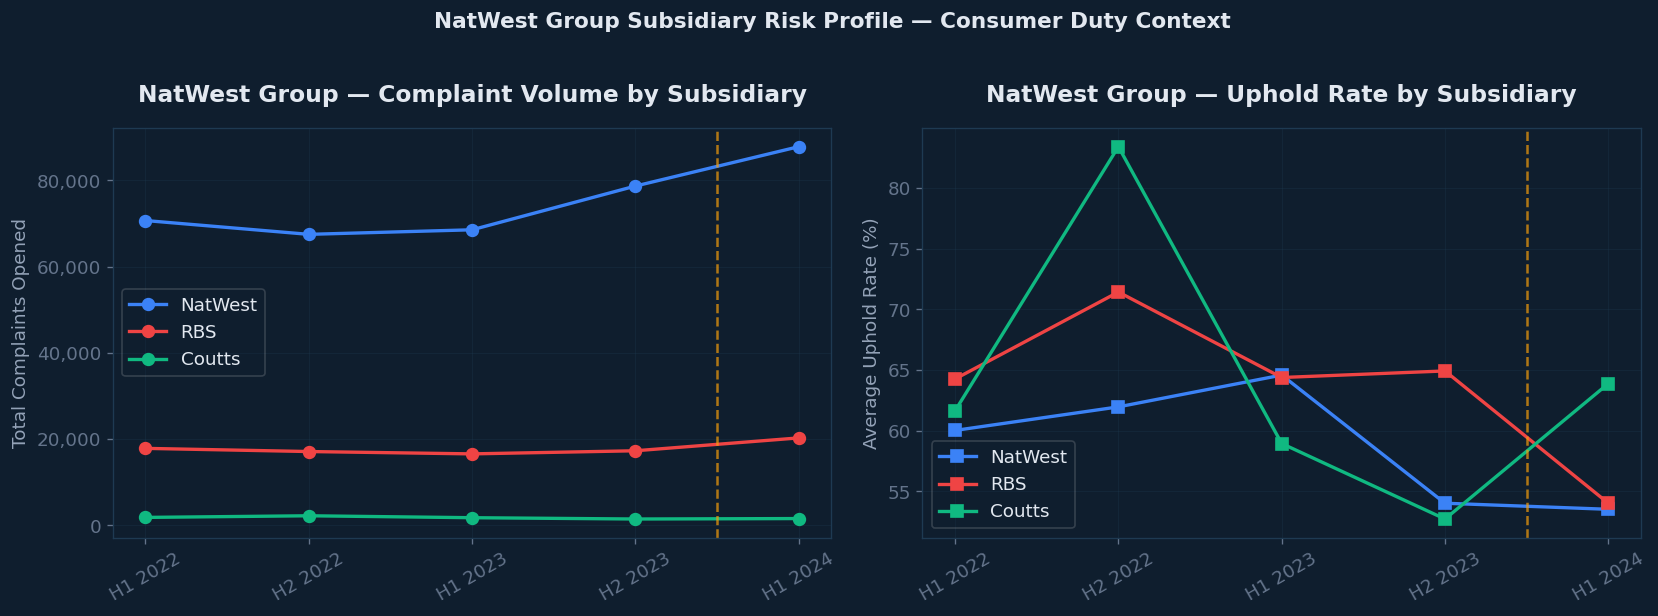

Chart saved.


In [21]:
# NatWest Group subsidiaries
natwest_firms = [
    'National Westminster Bank Plc',
    'The Royal Bank of Scotland Plc',
    'Coutts & Company'
]

nw_data = (
    df[df['firm_name'].isin(natwest_firms)]
    .groupby(['firm_name', 'period_label', 'period_order', 'pre_post_duty'])
    .agg(
        total_opened=('complaints_opened', 'sum'),
        avg_upheld=('upheld_pct', 'mean')
    )
    .reset_index()
    .sort_values('period_order')
)

firm_colours = {
    'National Westminster Bank Plc': BLUE,
    'The Royal Bank of Scotland Plc': RED,
    'Coutts & Company': GREEN
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0F1E2E')

for firm, colour in firm_colours.items():
    sub = nw_data[nw_data['firm_name'] == firm]
    if len(sub) == 0:
        continue
    short = firm.replace('The Royal Bank of Scotland Plc', 'RBS')\
                .replace('National Westminster Bank Plc', 'NatWest')\
                .replace('Coutts & Company', 'Coutts')

    ax1.plot(sub['period_label'], sub['total_opened'],
             color=colour, marker='o', linewidth=2,
             markersize=7, label=short)
    ax2.plot(sub['period_label'], sub['avg_upheld'],
             color=colour, marker='s', linewidth=2,
             markersize=7, label=short)

# Consumer Duty line
for ax in [ax1, ax2]:
    periods = nw_data['period_label'].unique()
    if 'H1 2023' in periods and 'H2 2023' in periods:
        plist = sorted(
            nw_data[['period_label','period_order']]
            .drop_duplicates()
            .sort_values('period_order')['period_label'].tolist()
        )
        if 'H2 2023' in plist:
            duty_x = plist.index('H2 2023') - 0.5
            ax.axvline(x=duty_x, color=AMBER, linewidth=1.5,
                       linestyle='--', alpha=0.7)

ax1.set_title('NatWest Group — Complaint Volume by Subsidiary')
ax1.set_ylabel('Total Complaints Opened')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.legend(framealpha=0.2)
ax1.grid(alpha=0.3)

ax2.set_title('NatWest Group — Uphold Rate by Subsidiary')
ax2.set_ylabel('Average Uphold Rate (%)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(framealpha=0.2)
ax2.grid(alpha=0.3)

plt.suptitle('NatWest Group Subsidiary Risk Profile — Consumer Duty Context',
             fontsize=13, fontweight='bold', y=1.02, color='#E2E8F0')
plt.tight_layout()
plt.savefig('./processed/chart_07_natwest_group_profile.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 8 - Consumer Duty Risk Index

**Question this chart answers:**  
If you had to rank every firm in the dataset by overall Consumer Duty risk - combining complaint volume, uphold rate, and trajectory - which firms should a regulator look at first?

**How the index is calculated:**  
A composite score weighted across four dimensions:
- Complaint volume (normalised) - 30%
- Average uphold rate - 35%
- Uphold rate trend (worsening or improving) — 20%
- Volume growth rate - 15%

*This is a transparent, documented analytical model - not a black box.*

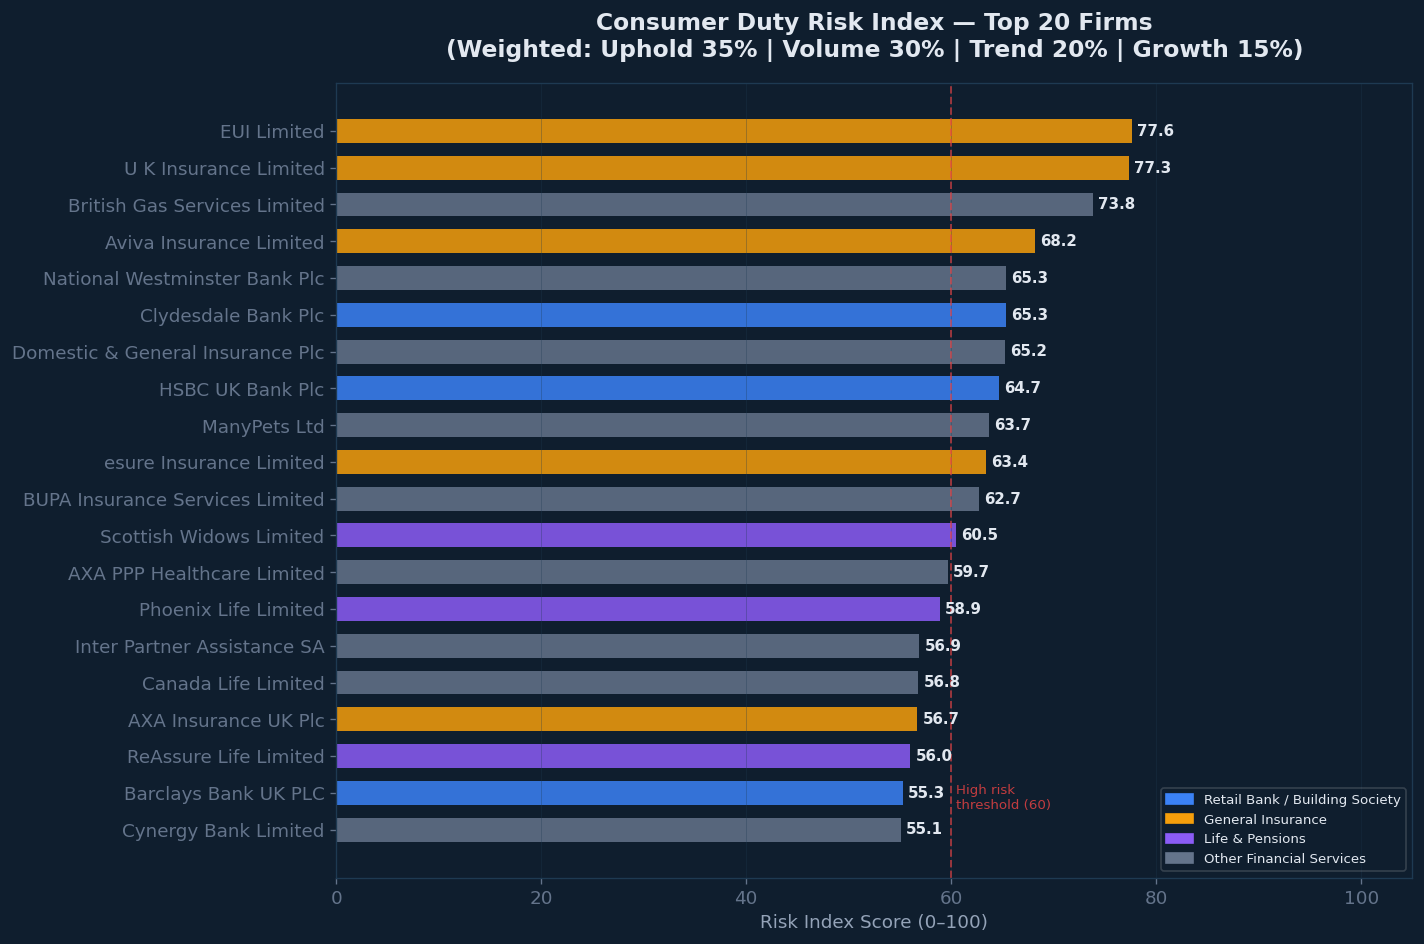

Risk index saved.
                       firm_name                      firm_type  risk_index  avg_upheld  total_opened  upheld_trend
                     EUI Limited              General Insurance        77.6   61.740000        206334      2.590000
           U K Insurance Limited              General Insurance        77.3   72.720000        206334     -1.070000
    British Gas Services Limited       Other Financial Services        73.8   76.133333        206334     -0.560000
         Aviva Insurance Limited              General Insurance        68.2   62.580000        206334      0.100000
   National Westminster Bank Plc       Other Financial Services        65.3   58.820000        206334     -2.094000
             Clydesdale Bank Plc Retail Bank / Building Society        65.3   63.860870        167292      0.114717
Domestic & General Insurance Plc       Other Financial Services        65.2   62.860000        206334     -4.180000
                HSBC UK Bank Plc Retail Bank / Buildin

In [22]:
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Build firm-level summary
risk_base = (
    df[df['upheld_pct'].notna()]
    .groupby('firm_name')
    .agg(
        total_opened=('complaints_opened', 'sum'),
        avg_upheld=('upheld_pct', 'mean'),
        firm_type=('firm_type', 'first'),
        periods=('period_label', 'nunique')
    )
    .reset_index()
)
risk_base = risk_base[risk_base['total_opened'] > 1000].copy()

# Uphold rate trend - slope of upheld_pct over period_order
def uphold_slope(firm):
    sub = df[df['firm_name']==firm][['period_order','upheld_pct']].dropna()
    if len(sub) < 2:
        return 0
    return np.polyfit(sub['period_order'], sub['upheld_pct'], 1)[0]

# Volume growth - first to last period
def volume_growth(firm):
    sub = (
        df[df['firm_name']==firm]
        .groupby('period_order')['complaints_opened'].sum()
        .sort_index()
    )
    if len(sub) < 2:
        return 0
    first, last = sub.iloc[0], sub.iloc[-1]
    if first == 0:
        return 0
    return (last - first) / first * 100

risk_base['upheld_trend']  = risk_base['firm_name'].apply(uphold_slope)
risk_base['volume_growth'] = risk_base['firm_name'].apply(volume_growth)

# Clip extreme outliers before scaling
for col in ['total_opened','avg_upheld','upheld_trend','volume_growth']:
    p5  = risk_base[col].quantile(0.05)
    p95 = risk_base[col].quantile(0.95)
    risk_base[col] = risk_base[col].clip(p5, p95)

# Normalise 0–100
scaler = MinMaxScaler(feature_range=(0, 100))
risk_base[['vol_score','upheld_score','trend_score','growth_score']] = scaler.fit_transform(
    risk_base[['total_opened','avg_upheld','upheld_trend','volume_growth']]
)

# Weighted composite
risk_base['risk_index'] = (
    risk_base['vol_score']    * 0.30 +
    risk_base['upheld_score'] * 0.35 +
    risk_base['trend_score']  * 0.20 +
    risk_base['growth_score'] * 0.15
).round(1)

# Top 20 by risk index
top_risk = (
    risk_base
    .sort_values('risk_index', ascending=False)
    .head(20)
    .sort_values('risk_index', ascending=True)
)

# Colour by firm type
bar_cols = [type_colours.get(ft, SLATE) for ft in top_risk['firm_type']]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_risk['firm_name'],
    top_risk['risk_index'],
    color=bar_cols, height=0.65, alpha=0.85
)

# Score labels
for bar, (_, row) in zip(bars, top_risk.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{row['risk_index']:.1f}",
        va='center', fontsize=9, color='#E2E8F0', fontweight='bold'
    )

# Threshold line at 60
ax.axvline(x=60, color=RED, linewidth=1.2,
           linestyle='--', alpha=0.6)
ax.text(60.5, 0.5, 'High risk\nthreshold (60)',
        color=RED, fontsize=8, va='bottom', alpha=0.8)

# Legend for firm types
handles = [mpatches.Patch(color=c, label=ft)
           for ft, c in type_colours.items()
           if ft in top_risk['firm_type'].values]
ax.legend(handles=handles, loc='lower right',
          framealpha=0.2, fontsize=8)

ax.set_title('Consumer Duty Risk Index — Top 20 Firms\n'
             '(Weighted: Uphold 35% | Volume 30% | Trend 20% | Growth 15%)')
ax.set_xlabel('Risk Index Score (0–100)')
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./processed/chart_08_risk_index.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()

# Save risk index table for README
risk_table = (
    risk_base
    .sort_values('risk_index', ascending=False)
    [['firm_name','firm_type','risk_index',
      'avg_upheld','total_opened','upheld_trend']]
    .head(15)
)
risk_table.to_csv('./processed/consumer_duty_risk_index.csv', index=False)
print('Risk index saved.')
print(risk_table.to_string(index=False))

## Chart 9 - Uphold Rate: Pre vs Post Consumer Duty by Firm Type

**Question this chart answers:**  
At the sector level - not individual firm level - did Consumer Duty make uphold rates better or worse? Which sectors responded to the regulation and which did not?

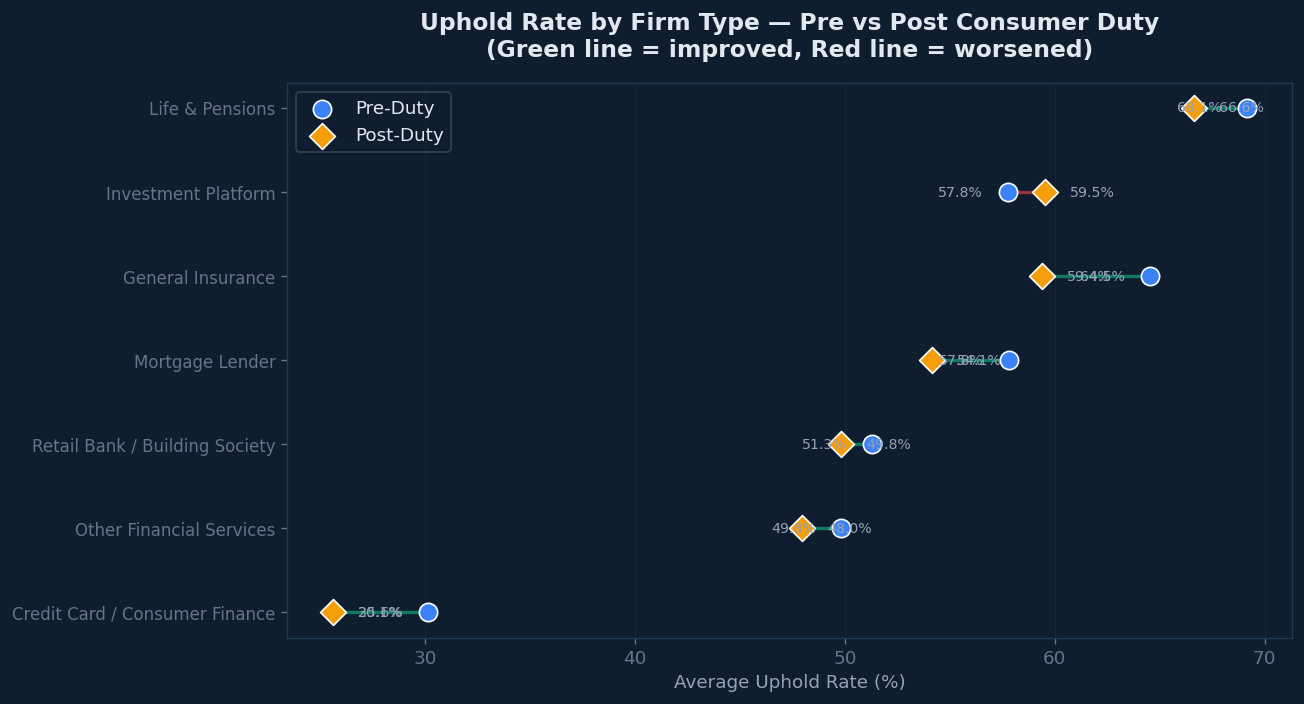

Chart saved.


In [23]:
type_duty = (
    df[df['upheld_pct'].notna()]
    .groupby(['firm_type', 'pre_post_duty'])
    ['upheld_pct']
    .mean()
    .reset_index()
)

# Pivot
type_pivot = type_duty.pivot(
    index='firm_type',
    columns='pre_post_duty',
    values='upheld_pct'
).dropna()

# Sort by post-duty uphold rate
if 'Post-Duty' in type_pivot.columns:
    type_pivot = type_pivot.sort_values('Post-Duty', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

y_pos = np.arange(len(type_pivot))

# Draw connecting lines first
for i, (ft, row) in enumerate(type_pivot.iterrows()):
    pre  = row.get('Pre-Duty', None)
    post = row.get('Post-Duty', None)
    if pre is not None and post is not None:
        colour = GREEN if post < pre else RED
        ax.plot([pre, post], [i, i], color=colour,
                linewidth=2, alpha=0.6, zorder=1)

# Pre-duty dots
if 'Pre-Duty' in type_pivot.columns:
    ax.scatter(type_pivot['Pre-Duty'], y_pos,
               color=PRE_COL, s=120, zorder=3,
               label='Pre-Duty', edgecolors='white', linewidth=1)

# Post-duty dots
if 'Post-Duty' in type_pivot.columns:
    ax.scatter(type_pivot['Post-Duty'], y_pos,
               color=POST_COL, s=120, zorder=3, marker='D',
               label='Post-Duty', edgecolors='white', linewidth=1)

# Value labels
for i, (ft, row) in enumerate(type_pivot.iterrows()):
    for col, offset in [('Pre-Duty', -3), ('Post-Duty', 3)]:
        if col in row and not np.isnan(row[col]):
            ax.text(row[col] + offset * 0.4, i,
                    f"{row[col]:.1f}%",
                    va='center', ha='left' if offset > 0 else 'right',
                    fontsize=8.5, color='#94A3B8')

ax.set_yticks(y_pos)
ax.set_yticklabels(type_pivot.index, fontsize=10)
ax.set_xlabel('Average Uphold Rate (%)')
ax.set_title('Uphold Rate by Firm Type — Pre vs Post Consumer Duty\n'
             '(Green line = improved, Red line = worsened)')
ax.legend(framealpha=0.2)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./processed/chart_09_uphold_pre_post_type.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Chart 10 - Monthly Volume by Product Category (Stacked)

**Question this chart answers:**  
How does the composition of complaints change across periods? Is one product category driving overall volume growth, or is it broad-based across all categories?

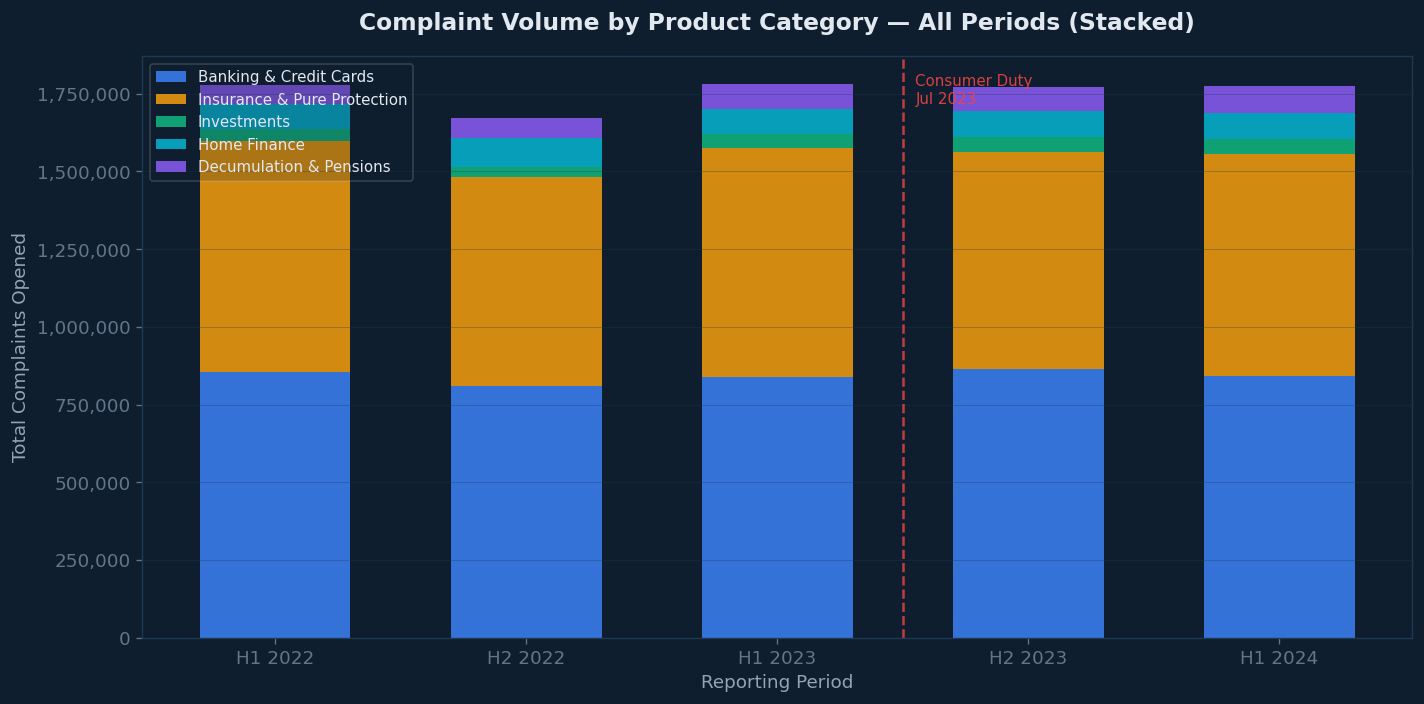

Chart saved.


In [24]:
cat_period = (
    df.groupby(['period_label', 'period_order', 'product_category'])
    ['complaints_opened']
    .sum()
    .reset_index()
    .sort_values('period_order')
)

stack_pivot = cat_period.pivot(
    index='period_label',
    columns='product_category',
    values='complaints_opened'
).fillna(0)

# Reorder by period_order
period_ord = (
    df[['period_label','period_order']]
    .drop_duplicates()
    .sort_values('period_order')
)
ordered = [p for p in period_ord['period_label'] if p in stack_pivot.index]
stack_pivot = stack_pivot.loc[ordered]

cat_colours = {
    'Banking & Credit Cards':     BLUE,
    'Insurance & Pure Protection': AMBER,
    'Investments':                GREEN,
    'Home Finance':               '#06B6D4',
    'Decumulation & Pensions':    '#8B5CF6',
}

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(stack_pivot))
for cat, colour in cat_colours.items():
    if cat not in stack_pivot.columns:
        continue
    vals = stack_pivot[cat].values
    ax.bar(
        stack_pivot.index, vals,
        bottom=bottom,
        color=colour, alpha=0.85,
        label=cat, width=0.6
    )
    bottom += vals

# Consumer Duty line
period_list = list(stack_pivot.index)
if 'H1 2023' in period_list and 'H2 2023' in period_list:
    duty_pos = period_list.index('H2 2023') - 0.5
    ax.axvline(x=duty_pos, color=RED, linewidth=1.5,
               linestyle='--', alpha=0.8)
    ax.text(duty_pos + 0.05,
            ax.get_ylim()[1] * 0.97,
            'Consumer Duty\nJul 2023',
            color=RED, fontsize=9, va='top', alpha=0.9)

ax.set_title('Complaint Volume by Product Category — All Periods (Stacked)')
ax.set_ylabel('Total Complaints Opened')
ax.set_xlabel('Reporting Period')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(loc='upper left', framealpha=0.2, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./processed/chart_10_stacked_category_volume.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1E2E')
plt.show()
print('Chart saved.')

## Summary

In [25]:
print('=' * 60)
print('KEY FINDINGS SUMMARY')
print('=' * 60)

total = df['complaints_opened'].sum()
firms = df['firm_name'].nunique()
periods = df['period_label'].nunique()
print(f'\nDataset: {total:,.0f} complaints | {firms} firms | {periods} periods')

pre  = df[df['pre_post_duty']=='Pre-Duty']['complaints_opened'].sum()
post = df[df['pre_post_duty']=='Post-Duty']['complaints_opened'].sum()
change = (post - pre) / pre * 100
print(f'\nPre-Duty total:  {pre:,.0f}')
print(f'Post-Duty total: {post:,.0f}')
print(f'Change:          {change:+.1f}%')

pre_upheld  = df[df['pre_post_duty']=='Pre-Duty']['upheld_pct'].mean()
post_upheld = df[df['pre_post_duty']=='Post-Duty']['upheld_pct'].mean()
print(f'\nPre-Duty avg upheld rate:  {pre_upheld:.1f}%')
print(f'Post-Duty avg upheld rate: {post_upheld:.1f}%')
print(f'Change:                    {post_upheld - pre_upheld:+.1f} percentage points')

# Danger quadrant count
scatter = (
    df[df['upheld_pct'].notna()]
    .groupby('firm_name')
    .agg(total_opened=('complaints_opened','sum'), avg_upheld=('upheld_pct','mean'))
    .reset_index()
)
scatter = scatter[scatter['total_opened'] > 1000]
med_vol = scatter['total_opened'].median()
med_uph = scatter['avg_upheld'].median()
danger_count = len(scatter[
    (scatter['total_opened'] > med_vol) &
    (scatter['avg_upheld'] > med_uph)
])
print(f'\nDanger quadrant firms: {danger_count}')

# Top risk firm
try:
    ri = pd.read_csv('./processed/consumer_duty_risk_index.csv')
    top1 = ri.iloc[0]
    print(f'Highest risk firm: {top1["firm_name"]} (Risk Index: {top1["risk_index"]:.1f})')
except:
    pass

print('\n' + '=' * 60)
print('All 10 charts saved to ./processed/')
print('=' * 60)

KEY FINDINGS SUMMARY

Dataset: 8,777,764 complaints | 291 firms | 5 periods

Pre-Duty total:  5,230,929
Post-Duty total: 3,546,835
Change:          -32.2%

Pre-Duty avg upheld rate:  52.8%
Post-Duty avg upheld rate: 51.1%
Change:                    -1.7 percentage points

Danger quadrant firms: 65
Highest risk firm: EUI Limited (Risk Index: 77.6)

All 10 charts saved to ./processed/
